# Introduction

In the lab work we are going to learn the following concepts
1. Read and display wav signals
2. Analyze the wave form of the signals to locate voiced and unvoiced sounds
3. Locate and display plosive sounds









In [2]:
# Needed imports
import numpy as np
from IPython.display import Audio
from scipy.io import wavfile
from scipy import signal
from scipy.signal import lfilter
from scipy.linalg import toeplitz

# display
import matplotlib.pyplot as plt
from bokeh.io import output_notebook, show
output_notebook()
from bokeh.layouts import gridplot
from bokeh.plotting import figure
import numpy as np



Loading BokehJS ...

# 1 Waveform


In this section we download two audios in .wav format of two speakers male and female uttering the phrase: "los barbaros invadieron en imperio romano". After downloading it and check the sampling frequency to be 16000Hz, we plot the waveform using matplotlib, just to check if there has been any problems with the format or the signal is saturated.


In [3]:
!wget http://dihana.cps.unizar.es/~cadrete/barbaros1.wav
!wget http://dihana.cps.unizar.es/~cadrete/barbaros2.wav
!ls

"wget" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.
"wget" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.
"ls" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


## Display waveform

In [4]:
fs, x1 = wavfile.read('barbaros1.wav')
plt.plot(x1)
Audio(x1,rate=fs)

FileNotFoundError: [Errno 2] No such file or directory: 'barbaros1.wav'

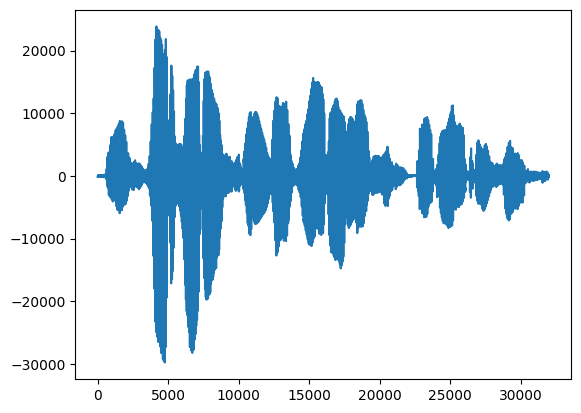

In [ ]:
fs, x2 = wavfile.read('barbaros2.wav')
plt.plot(x2)
Audio(x2,rate=fs)

The previous plots do not allow to perform a detailed study, therefore we display the signal using a more advanced tool that allows to zoom the desired regions.

In [ ]:
def plot_time(x, fs, title=''):
    t = np.linspace(0, len(x)/fs - 1/fs, len(x))

    f1 = figure(
        title=title,
        tools='wheel_zoom,box_zoom,reset,save',
        x_axis_label='t (s)',
        width=1000,
        height=400
    )

    f1.line(t, x, legend_label=title)
    show(gridplot([[f1]]))

def plot_samples(x, title=''):
    t = np.arange(len(x))

    f1 = figure(
        title=title,
        tools='hover,wheel_zoom,box_zoom,reset,save',
        x_axis_label='n (samples)',
        width=1000,
        height=400
    )

    f1.line(t, x, legend_label=title)
    show(gridplot([[f1]]))

plot_samples(x1, 'x1[n]')



In [ ]:
Audio(x1,rate=fs)

In [ ]:
#plot_time(x2, 'x2(t)')
plot_samples(x2, 'x2[n]')
Audio(x2,rate=fs)

## Exercises

### Exercise 1.1 Voiced sounds
Locate two [voiced sounds](https://en.wikipedia.org/wiki/Phonetics) and comment the waveform, plot them and play the sound corresponding to the selected samples.

Can you estimate the pith frequency ?

In [ ]:
# example solution
plot_samples(x1[4000:5000], 'x1[n]')
Audio(x1[4000:5000],rate=fs)

In [ ]:
# 1.1 insert your two selections here: display them and listen to them

### Exercise 1.2 Unvoiced sounds
Locate two [unvoiced sounds](https://en.wikipedia.org/wiki/Phonetics) and comment the waveform, plot them and play the sound corresponding to the selected samples.

In [ ]:
# 1.2 insert your two selections here: display them and listen to them

In [ ]:
# 1.2 solution
plot_samples(x1[11400:12400], 'x1[n]')
Audio(x1[11400:12400],rate=fs)

In [ ]:
# 1.2 solution
plot_samples(x2[1900:3700], 'x1[n]')
Audio(x2[1900:3700],rate=fs)

In [ ]:
# 1.2 solution
plot_samples(x1[500:2000], 'x1[n]')
Audio(x1[500:2000],rate=fs)

### Exercise 1.3 Plosive sounds
Locate two [plosive sounds](https://en.wikipedia.org/wiki/Articulation_(phonetics)) and comment the waveform, plot them and play the sound corresponding to the selected samples.


In [ ]:
# 1.3 insert your two selections here: display them and listen to them

In [ ]:
# 1.3 solution
plot_samples(x1[25400:28000], 'x1[n]')
Audio(x1[25500:28000],rate=fs)

### Exercise 1.4 Other sounds

Locate two different sounds (nasal, velar, palatal) and comment the waveform, plot them and play the sound corresponding to the selected samples.


In [ ]:
# 1.4 insert your two selections here: display them and plot them

In [ ]:
# 1.4 solution
plot_samples(x2[10500:13000], 'x1[n]')
Audio(x2[10500:13000],rate=fs)

# 2. Localized analysis

In general the localized analysis can be expressed as:


$Q_n = \sum_{m=-\infty}^{\infty} T(x[m] \cdot w[n-m])$

with $ w[n]$ the window, usually a Hamming type.

## Windowing
Usually for speech signals we use a window of analsys of 20-30ms and an advance step of 10ms. You can try chaning these setting later.

In [ ]:
def windowing(x, Ns=0.025, Ms=0.010, fs=16000):
    N = int(Ns * fs)
    M = int(Ms * fs)
    T = len(x)
    m = np.arange(0, T - N, M).reshape(1, -1)
    L = len(m)
    ind = np.arange(N).reshape(-1, 1).dot(np.ones((1, L))) + np.ones((N, 1)).dot(m)
    return x[ind.astype(int).T].astype(np.float32)


# using the windowing function and passing the signal x1 as input we obtain a matrix X1 with the windows as rows.
X1 = windowing(x1)
print(X1.shape)
print('number of windows:     %d' % X1.shape[0])
print('window size (samples): %d' % X1.shape[1])


(229, 400)
number of windows:     229
window size (samples): 400


Now we apply the [hamming window](https://en.wikipedia.org/wiki/Window_function#Hamming_window).

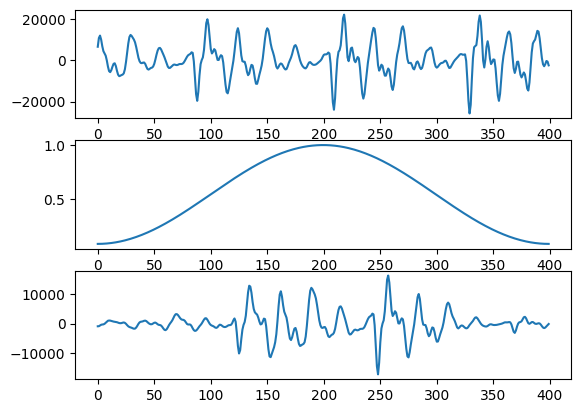

In [ ]:
def hamming(X):
    w = np.hamming(X.shape[1])
    return X * w

X1w = hamming(X1)

# the voiced sound given as example in exercise 1.1 was at sample 4200, which means window 4200 (samples)/160 (samples/window) ~= 26
plt.subplot(3,1,1)
plt.plot(X1[26])
plt.subplot(3,1,2)
plt.plot(np.hamming(X1.shape[1]))
plt.subplot(3,1,3)
plt.plot(X1w[25])

## Energy
One of the simplest analysis that we can perform is to obtain the energy. If we compute the energy of each window we can observe the energy envelope of the signal, which can be used to build a basic VAD [voice activity detector](https://en.wikipedia.org/wiki/Voice_activity_detection).


(0.0, 229.0)

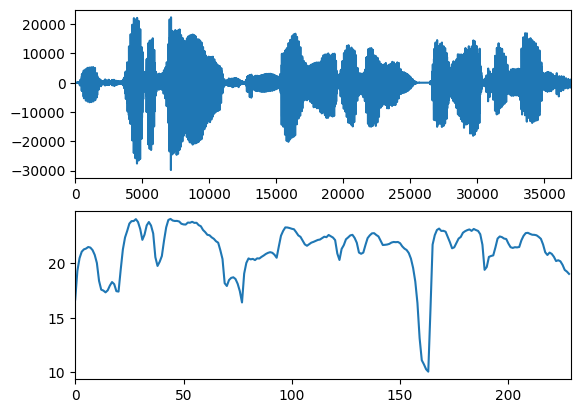

In [ ]:
E1 = np.log(np.sum(X1*X1, axis=1))

# plot of the signal and the loc. energy
plt.subplot(2,1,1)
plt.plot(x1)
plt.xlim([0, len(x1)])
plt.subplot(2,1,2)
plt.plot(E1)
plt.xlim([0, len(E1)])

## Frequency
We apply the [Fourier Transform](Fourier Transform) and the module to obtain the energy of the signal at each frequency. To compute it fast FFT algorithm is usually employed.


(229, 256)


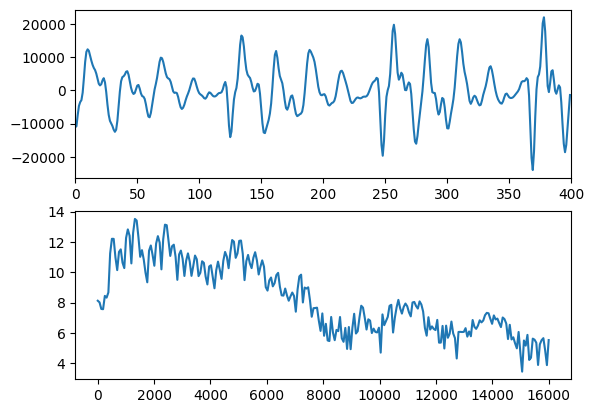

In [ ]:
def frequency_transform(X, NFFT=None):
    if NFFT is None:
        NFFT = int(2 ** np.ceil(np.log2(X.shape[1])))
    Xfreq = np.abs(np.fft.fft(X, NFFT, axis=1))
    return Xfreq[:, :(NFFT // 2)]


X1f = frequency_transform(X1w)
print(X1f.shape)

# the voiced sound given as example in exercise 1.1
f = np.linspace(0, fs, X1f.shape[1])
plt.subplot(2,1,1)
plt.plot(X1[25])
plt.xlim([0, len(X1[26])])

plt.subplot(2,1,2)
plt.plot(f, np.log( X1f[26] ))

Another interesting visualization that we can generate is the spectrogram, which allows to observe the spectral components evolution through time

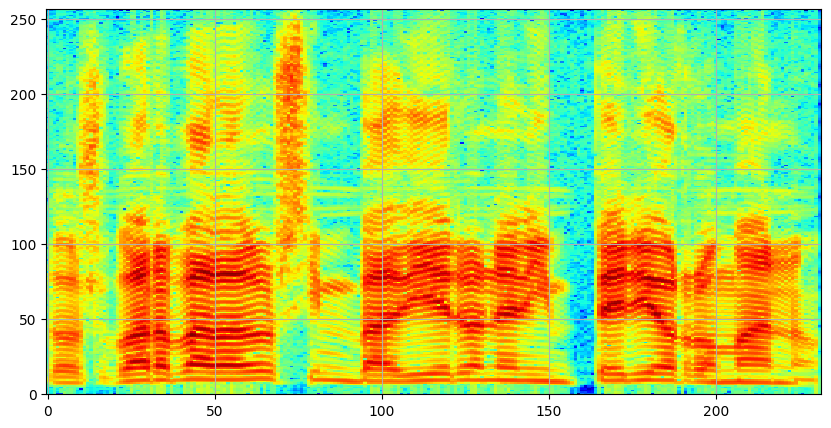

In [ ]:
fig=plt.figure(figsize=(10, 5))
plt.imshow(np.log(X1f.T), cmap='jet', interpolation='none',origin='lower', aspect='auto')
plt.grid(None)

In [ ]:
def image(x, title=''):
    h, w = x.shape

    f = figure(
        title=title,
        tools='wheel_zoom,box_zoom,reset,save',
        x_range=(0, w),
        y_range=(0, h),   # origin='lower' behavior
        width=800,
        height=300        # aspect='auto' (pick whatever ratio you want)
    )

    f.image(
        image=[x],
        x=0, y=0,
        dw=w, dh=h,
        palette="Spectral11"
    )

    show(f)

# example
image(np.log(X1f.T))

## Autocorrelation
The [autorrelation](https://en.wikipedia.org/wiki/Autocorrelation) is a useful tool to analize voiced and unvoiced sounds.

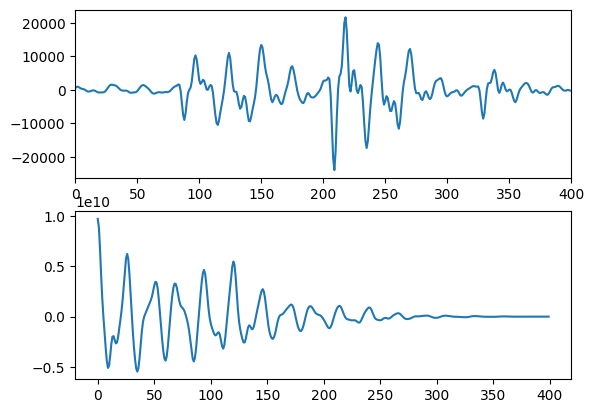

In [ ]:
def autocorrelation(X, NFFT=None):
    NFFT = int(2 ** np.ceil(np.log2(X.shape[1]))) * 2
    Xfreq = np.fft.fft(X, NFFT, axis=1)
    Xa = np.fft.ifft(Xfreq * np.conj(Xfreq), NFFT, axis=1)
    return np.real( Xa[:,:X.shape[1]] )


X1a = autocorrelation(X1w)
#print(X1a.shape)

# the voiced sound given as example in exercise 1.1
plt.subplot(2,1,1)
plt.plot(X1w[26])
plt.xlim([0, len(X1w[26])])

plt.subplot(2,1,2)
plt.plot( X1a[26] )

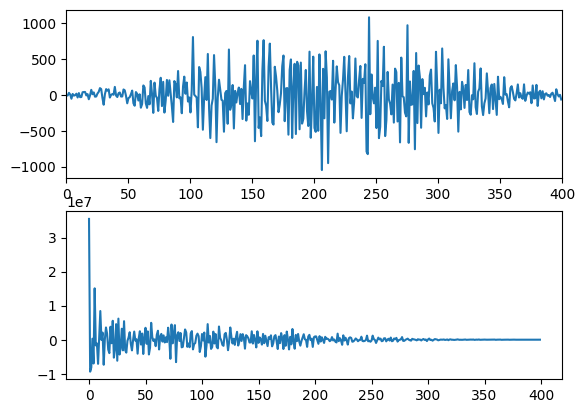

In [ ]:
# An unvoiced sound given as example in exercise 1.2
plt.subplot(2,1,1)
plt.plot(X1w[71])
plt.xlim([0, len(X1w[71])])

plt.subplot(2,1,2)
plt.plot( X1a[71] )

## Linear prediction
We use [linear prediction](https://en.wikipedia.org/wiki/Linear_prediction) to analize voiced sounds since it is well suited to model all pole systems as the resonances formed in the vocal tract in our case, see this [example](https://ccrma.stanford.edu/~hskim08/lpc/).


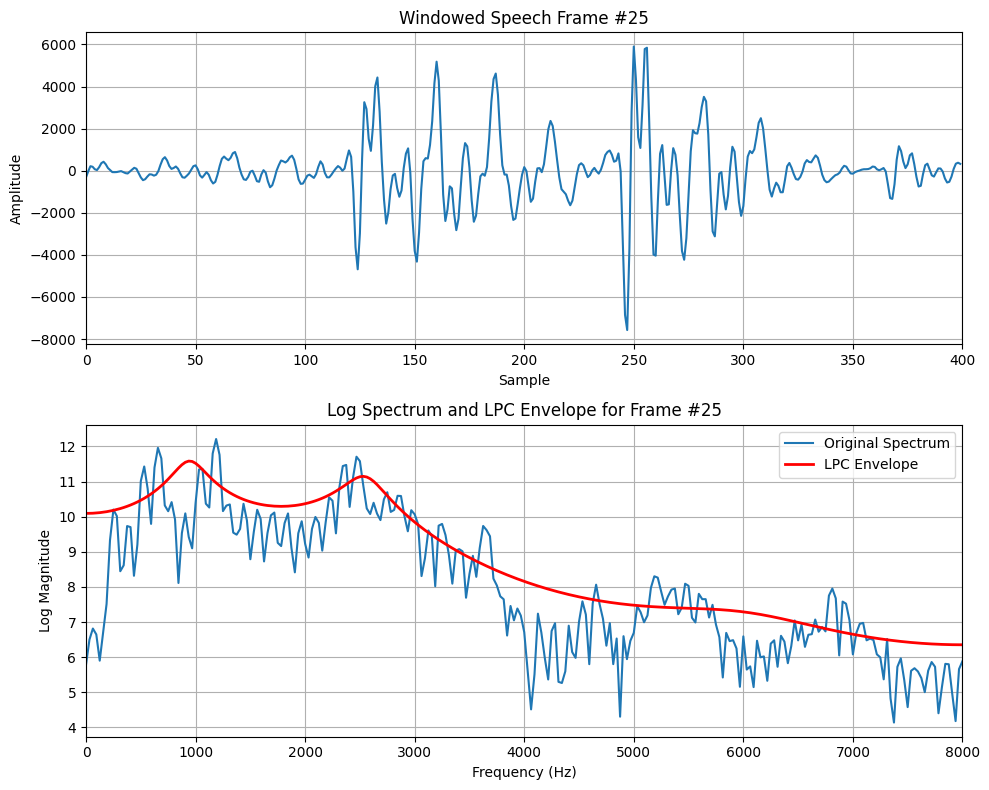

In [ ]:
def windowing2(x, fs=16000, Ns=0.025, Ms=0.010):
    N = int(Ns * fs)
    M = int(Ms * fs)
    n = (len(x) + M - 1) // M
    T = (n - 1) * M + N
    xa = x.copy()
    if T > len(x):
        xa.resize(T, refcheck=False)
    m = np.arange(0, n * M, M)
    ind = np.arange(N).reshape(-1, 1) + m.reshape(1, -1)
    return xa[ind.astype(int).T].astype(np.float32)
def lpc(signal, order):
    """
    Computes Linear Predictive Coding (LPC) coefficients using the Levinson-Durbin recursion.

    Args:
    signal (np.ndarray): A 2D array of windowed signal frames (num_frames x frame_size).
    order (int): The order of the LPC model.

    Returns:
    tuple: A tuple containing:
        - lpc_coeffs (np.ndarray): LPC coefficients for each frame ([1, -a1, -a2, ...]).
        - error (np.ndarray): Prediction error (gain) for each frame.
        - k (np.ndarray): Reflection coefficients for each frame.
    """
    num_frames, frame_size = signal.shape
    lpc_coeffs = np.zeros((num_frames, order + 1))
    error = np.zeros(num_frames)
    reflection_coeffs = np.zeros((num_frames, order))

    for i in range(num_frames):
        frame = signal[i, :]

        # Autocorrelation
        r = np.correlate(frame, frame, mode='full')[frame_size-1:frame_size+order]

        # Levinson-Durbin
        if r[0] == 0:
            lpc_coeffs[i, 0] = 1.0
            continue

        a = np.zeros(order + 1)
        k = np.zeros(order)
        E = r[0]

        a[0] = 1.0

        for j in range(1, order + 1):
            # Calculate reflection coefficient
            alpha_num = r[j] + np.dot(a[1:j], r[j-1:0:-1])
            alpha_den = E
            if alpha_den == 0: # Avoid division by zero
                alpha = 0
            else:
                alpha = -alpha_num / alpha_den

            k[j-1] = alpha

            # --- START OF FIX ---
            # Original buggy line:
            # a[1:j+1] += alpha * a[j-1:0:-1]

            # Corrected update logic:
            # 1. First, set the new j-th coefficient.
            a[j] = alpha
            # 2. Then, update the previous coefficients a[1]...a[j-1].
            # This uses the values of 'a' from *before* the new 'alpha' was added.
            if j > 1:
                a[1:j] += alpha * a[j-1:0:-1]
            # --- END OF FIX ---

            # Update error
            E *= (1 - alpha**2)

        lpc_coeffs[i, :] = a
        error[i] = E
        reflection_coeffs[i, :] = k

    return lpc_coeffs, error, reflection_coeffs


def frequency_transform_lpc(lpc_coeffs, n_fft):
    """
    Calculates the frequency response of the LPC inverse filter A(z).
    The magnitude of this is |A(e^jω)|.
    """
    num_frames = lpc_coeffs.shape[0]
    # Use rfft for real-valued signals, it's more efficient
    freq_response = np.abs(np.fft.rfft(lpc_coeffs, n=n_fft, axis=1))
    return freq_response



# Define analysis parameters
p = 8         # LPC order (8-12 is common for speech)
n_fft = 512    # FFT size for spectral analysis

# 1. Pre-emphasis: This is a high-pass filter to boost high frequencies.
#    Using lfilter is the correct way to apply this FIR filter.
x1_preemp = lfilter([1, -0.9375], 1, x1)

# 2. Windowing
X1w = windowing2(x1_preemp, fs=fs, Ns=0.025, Ms=0.010)

# 3. Apply Hamming window to each frame
N = X1w.shape[1]
window = np.hamming(N)
X1w_preemp = X1w * window

# 4. LPC Analysis
X1lpc, X1lpc_e, X1lpc_k = lpc(X1w_preemp, p)

# 5. Calculate the spectral envelope from LPC coefficients
#    The spectral envelope is G / |A(e^jω)|, where G is gain (sqrt of prediction error).
#    The log spectrum is log(G) - log(|A(e^jω)|).
X1lpc_freq_A = frequency_transform_lpc(X1lpc, n_fft)
# Add a small epsilon to avoid log(0)
epsilon = 1e-10
log_lpc_envelope = np.log(np.sqrt(X1lpc_e[:, np.newaxis])) - np.log(X1lpc_freq_A + epsilon)

# 6. Calculate the actual spectrum of the windowed frames for comparison
X1f = np.abs(np.fft.rfft(X1w_preemp, n=n_fft, axis=1))
log_X1f = np.log(X1f + epsilon)

# --- Plotting ---
frame_to_plot = 25


# Subplot 1: The windowed speech frame
plt.figure(figsize=(10, 8))
plt.subplot(2, 1, 1)
plt.plot(X1w_preemp[frame_to_plot])
plt.title(f'Windowed Speech Frame #{frame_to_plot}')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.xlim([0, len(X1w_preemp[frame_to_plot])])
plt.grid(True)

# Subplot 2: Log spectrum and LPC envelope
plt.subplot(2, 1, 2)
# Create the frequency axis for the plot
f = np.fft.rfftfreq(n_fft, 1/fs)

# Plot the original log spectrum (blue)
plt.plot(f, log_X1f[frame_to_plot], label='Original Spectrum')
# Plot the LPC spectral envelope (red)
plt.plot(f, log_lpc_envelope[frame_to_plot], 'r', linewidth=2, label='LPC Envelope')

plt.title(f'Log Spectrum and LPC Envelope for Frame #{frame_to_plot}')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Log Magnitude')
plt.xlim([0, fs / 2])
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

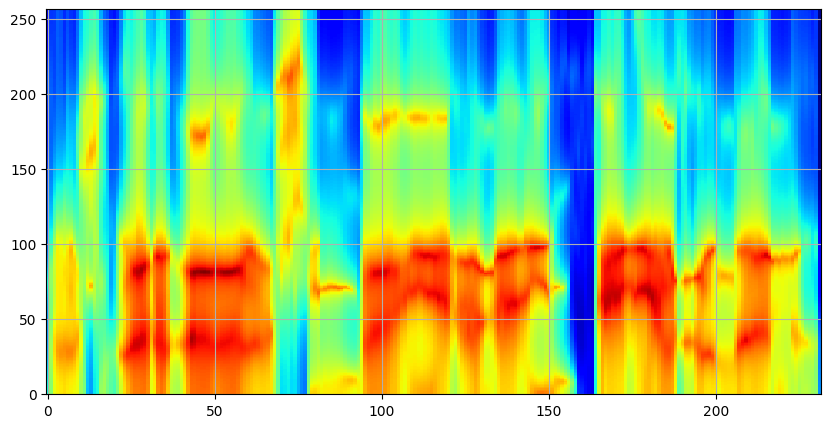

In [ ]:
fig=plt.figure(figsize=(10, 5))
plt.imshow(log_lpc_envelope.T, cmap='jet', interpolation='none',origin='lower', aspect='auto')
plt.grid(None)

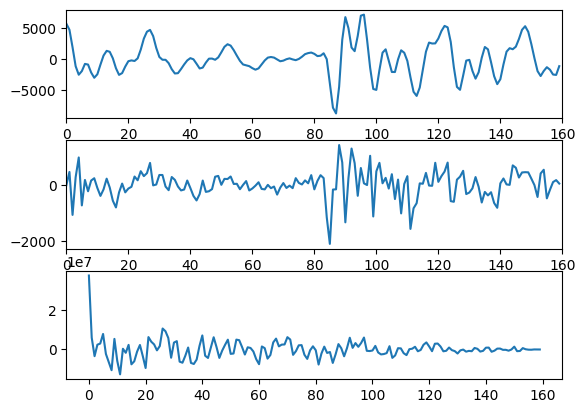

In [ ]:
# Autocorrelation of the prediction error
def filter_lpc(X, A):
  E = np.zeros_like(X)
  z = np.zeros(A.shape[1]-1)
  for i in range(len(X)):
    E[i],z = lfilter(A[i], 1, X[i], zi=z) #np.convolve(X[i], A[i],'same')
  return E

X1w_preemp = windowing2(np.convolve([1., -0.93], x1-np.mean(x1)),Ns=0.010, Ms=0.010)

X1lpc_err = filter_lpc(X1w_preemp, X1lpc)


#
X1alpc_err = autocorrelation(X1lpc_err)
#print(X1a.shape)

# the voiced sound given as example in exercise 1.1
plt.subplot(3,1,1)
plt.plot(X1w_preemp[26])
plt.xlim([0, len(X1w_preemp[26])])

plt.subplot(3,1,2)
plt.plot(X1lpc_err[26])
plt.xlim([0, len(X1lpc_err[26])])

plt.subplot(3,1,3)
plt.plot( X1alpc_err[26] )

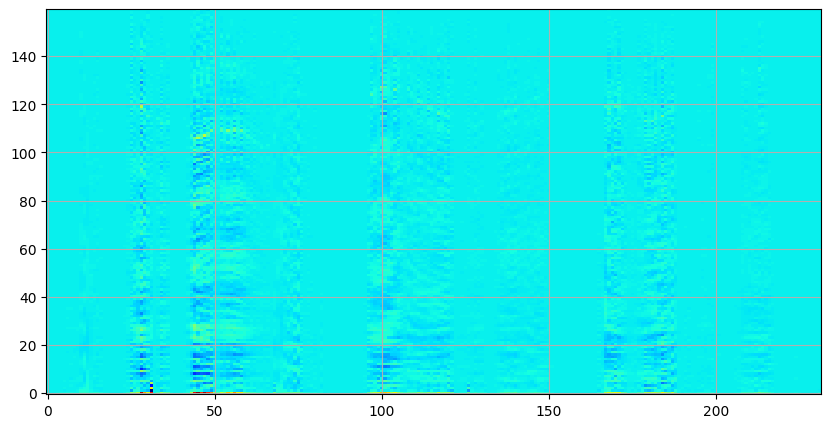

In [ ]:
fig=plt.figure(figsize=(10, 5))
plt.imshow(X1alpc_err[:].T, cmap='jet', interpolation='none',origin='lower', aspect='auto')
plt.grid(None)
#image(X1alpc_err.T)

Audio(X1alpc_err.reshape(-1),rate=fs)

## Cepstrum
The [real cepstrum](https://en.wikipedia.org/wiki/Cepstrum) representation has interesting properties as the blind deconvolution of signals as sum and the decorrelation of the spectral information


(232, 512)


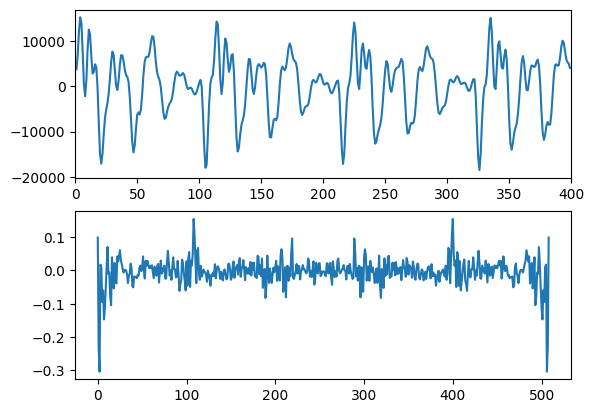

In [ ]:
def cepstrum(X, NFFT=None):
    if NFFT is None:
        NFFT = int(2 ** np.ceil(np.log2(X.shape[1])))
    Xfreq = np.abs( np.fft.fft(X, NFFT, axis=1) )
    Xceps = np.real( np.fft.ifft( np.log(Xfreq), axis=1 ))
    return Xceps


X1c = cepstrum(X1w)
print(X1c.shape)

# the voiced sound given as example in exercise 1.1
f = np.linspace(0, fs, X1f.shape[1])
plt.subplot(2,1,1)
plt.plot(X1[50])
plt.xlim([0, len(X1[26])])

plt.subplot(2,1,2)
plt.plot( X1c[50][2:-1] )

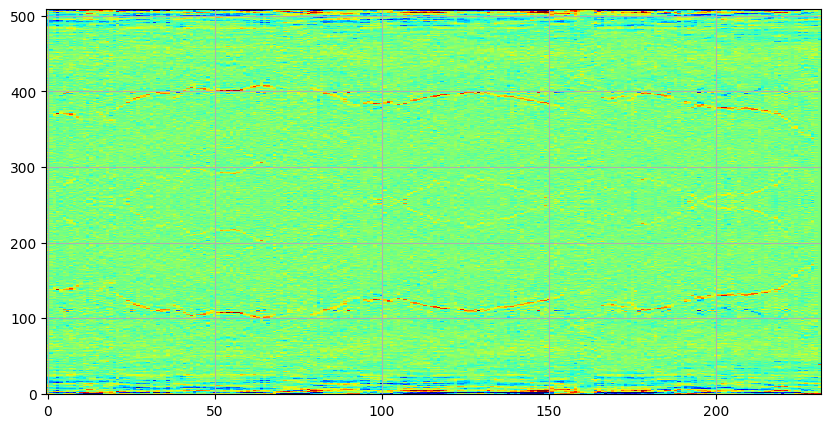

In [ ]:
fig=plt.figure(figsize=(10, 5))
plt.imshow( X1c[:,2:-1].T, cmap='jet', interpolation='none',origin='lower', aspect='auto')
plt.clim([-.3, 0.3])
plt.grid(None)

## Mel Filter Bank
The filter bank is a method to average the energy inside bandwidths trying to emulate the perception in the human auditory system. Lower bands will be narrower than higher bands since we have more sensitivity to lower frequencies.

This is the filter bank in the ETSI standard, using mel scale.
[ETSI ES 202 050](https://www.etsi.org/deliver/etsi_es/202000_202099/202050/01.01.05_60/es_202050v010105p.pdf)

We usually select B=24 filter banks, since it is related to the number of [critical bands](https://en.wikipedia.org/wiki/Critical_band) in the perceptual system .

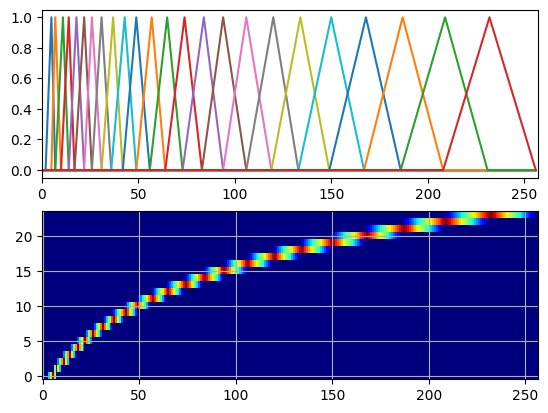

In [ ]:
def fb_etsi(F, B, fs=16000):
    StFreq = 64.0
    fb = np.zeros((F, B))
    # /* Constants for calculation*/
    start_mel = 2595.0 * np.log10(1.0 + StFreq / 700)
    fs_per_2_mel = 2595.0 * np.log10(1.0 + (fs / 2) / 700)
    for b in range(B):
        # /* Calculating mel-scaled frequency and the corresponding FFT-bin */
        # /* number for the lower edge of the band                          */
        freq = 700 * (np.power(10.0, (start_mel + (b) / (B + 1) * (fs_per_2_mel - start_mel)) / 2595) - 1.0)
        f1 = (2 * F * freq / fs + 0.5)
        # /* Calculating mel-scaled frequency for the upper edge of the band */
        freq = 700 * (
        np.power(10.0, (start_mel + (b + 2) / (B + 1) * (fs_per_2_mel - start_mel)) / 2595) - 1.0)
        # /* Calculating and storing the length of the band in terms of FFT-bins*/
        f3 = (2 * F * freq / fs + 0.5)
        f2 = (f1 + f3) / 2
        f3 = min(f3, F - 1)
        f1 = int(f1)
        f2 = int(f2)
        f3 = int(f3)
        for f in range(f1, f2):
            fb[f, b] = f * (1 / (f2 - f1)) - f1 / (f2 - f1)
        for f in range(f2, f3):
            fb[f, b] = f * (-1 / (f3 - f2)) + f3 / (f3 - f2)
    return fb


fb = fb_etsi(X1f.shape[1], 24)


plt.subplot(2,1,1)
plt.plot(fb)
plt.xlim([0, len(fb)])
plt.subplot(2,1,2)
plt.imshow(fb.T, cmap='jet', interpolation='none',origin='lower', aspect='auto')
plt.grid(None)

It is convenient the matrix form of the filter bank fb since we can apply to the frequency spectrum X1f using a matrix multiplication, and can obtain the log filter bank ouptput, which is used in many speech applications.

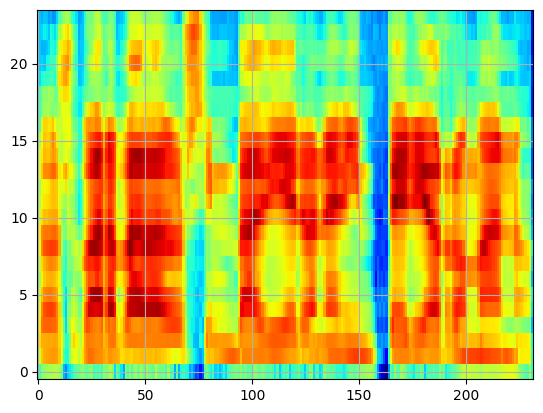

In [ ]:
def filter_bank(Xf, B=24, fs=16000, norm=True):
  fb = fb_etsi(Xf.shape[1], 24)
  if norm:
    fb = fb / fb.sum(axis=0, keepdims=True)
  return np.log( np.dot( Xf, fb ) )

X1logfb = filter_bank(X1f)

plt.imshow(X1logfb.T, cmap='jet', interpolation='none',origin='lower', aspect='auto')
plt.grid(None)

## Mel cepstrum
In the [mel cepstrum](https://en.wikipedia.org/wiki/Mel-frequency_cepstrum) (MFCC) the log spectrum is substituted by the log filter bank output and the inverse Fourier transform is substituted by a truncated DCT [discrete cosine transform](https://en.wikipedia.org/wiki/Discrete_cosine_transform). Both properties are kept to a certain extent, the convolutions can be considered close to a sum and the MFCC is more decorrelated than the filter bank outputs.

True


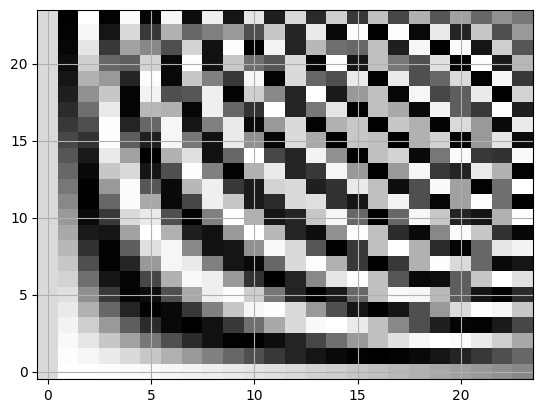

In [ ]:
def f_base_dct(N):
    b = np.zeros((N, N))
    for n in range(N):
        if n == 0:
            kn = np.sqrt(1 / N)
        else:
            kn = np.sqrt(2 / N)
        for m in range(N):
            b[m, n] = kn * np.cos((2 * m + 1) * n * np.pi / (2 * N))
    return b

dct = f_base_dct(24)

# it is an orthonormal base
np.set_printoptions(1)
print(np.allclose( np.dot( dct, dct.T ), np.eye(24)))

plt.imshow(dct, cmap='gray', interpolation='none',origin='lower', aspect='auto')
plt.grid(None)

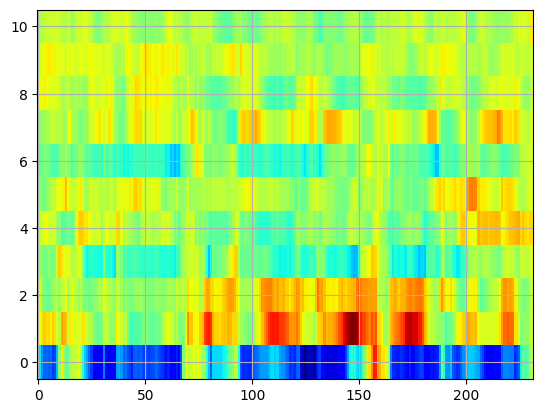

In [ ]:
def mfcc(Xlogfb, C=12):
  dct = f_base_dct(24)[:, :C+1]    # truncated dct, less detailed representation, high frequency vectors of the base
  return np.dot( Xlogfb, dct)[:,2:]  # first coefficient is an average of the energies, many times it is discarded


X1mfcc = mfcc(X1logfb)
plt.imshow(X1mfcc.T, cmap='jet', interpolation='none',origin='lower', aspect='auto')
plt.grid(None)

## Derivatives
A simple method to add context to our representations is to calculate a discrete derivative of the evolution of each mfcc through time.
This can be performed using the ETSI derivative filters to calculate what it is usally called speed and acceleration or [delta delta-delta](https://en.wikipedia.org/wiki/Mel-frequency_cepstrum).

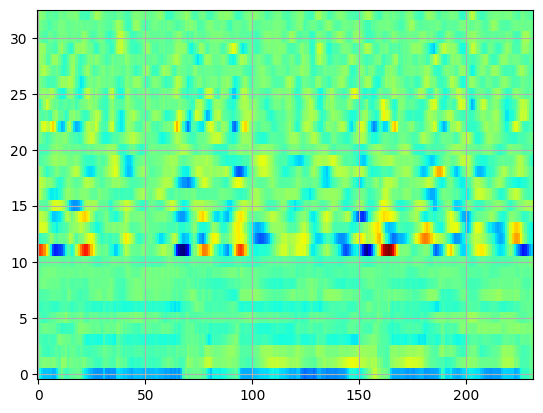

In [ ]:
def derivatives(x):
    d1 = np.array([[ -1.00,  -0.75,  -0.50, -0.25, +0.00, +0.25, +0.50 ,+0.75 ,+1.00]])
    d2 = np.array([[ +1.00 , +0.25,  -0.28, -0.61, -0.71, -0.61, -0.28 , 0.25 , 1.00]])
    xd1 = signal.convolve2d(x, d1.T, mode='same')
    xd2 = signal.convolve2d(x, d2.T, mode='same')
    return np.concatenate([x, xd1, xd2], axis=1)

X1dmfcc = derivatives(X1mfcc)

plt.imshow(X1dmfcc.T, cmap='jet', interpolation='none',origin='lower', aspect='auto')
plt.grid(None)

## Mean subtraction
The subtraction of the mean of the cepstrum or mfcc (also called [cepstrum mean subtraction](https://en.wikipedia.org/wiki/Cepstral_mean_and_variance_normalization) CMS) contributes to the blind equalization of the channel and microphone making the representation less vulnerable to missmatch due to a change in the channel or the microphone.

In [ ]:
def cms(x):
    return x - x.mean(axis=0, keepdims=True)

X1 = cms(X1dmfcc)

## Variance normalization
Sometimes it is also beneficial to normalize the variance of the features.

In [ ]:
def cmvn(x):
    x = x - x.mean(axis=0, keepdims=True)
    return x / x.std(axis=0, keepdims=True)

X1 = cmvn(X1dmfcc)

## Feature extraction for speech technologies

In summary a common feature extraction for speech and speaker recognition can be obtained as follows.


In [ ]:
X1 = cms(derivatives(mfcc(filter_bank(frequency_transform(hamming(windowing(x1)))))))
X2 = cms(derivatives(mfcc(filter_bank(frequency_transform(hamming(windowing(x2)))))))

### Similarity in the feature space
One of the advantages of a feature extraction like this is that a simple euclidean distances can provide a metric for sound similarity,

In [ ]:
!wget http://dihana.cps.unizar.es/~cadrete/audio1_s.16k.wav &> /dev/null
fs, x3 = wavfile.read('audio1_s.16k.wav')
Audio(x3,rate=fs)

In [ ]:
!wget http://dihana.cps.unizar.es/~cadrete/audio1_t1.16k.wav &> /dev/null
fs, x4 = wavfile.read('audio1_t1.16k.wav')
Audio(x4,rate=fs)

In [ ]:
!wget http://dihana.cps.unizar.es/~cadrete/audio1_t2.16k.wav &> /dev/null
fs, x5 = wavfile.read('audio1_t2.16k.wav')
Audio(x5,rate=fs)

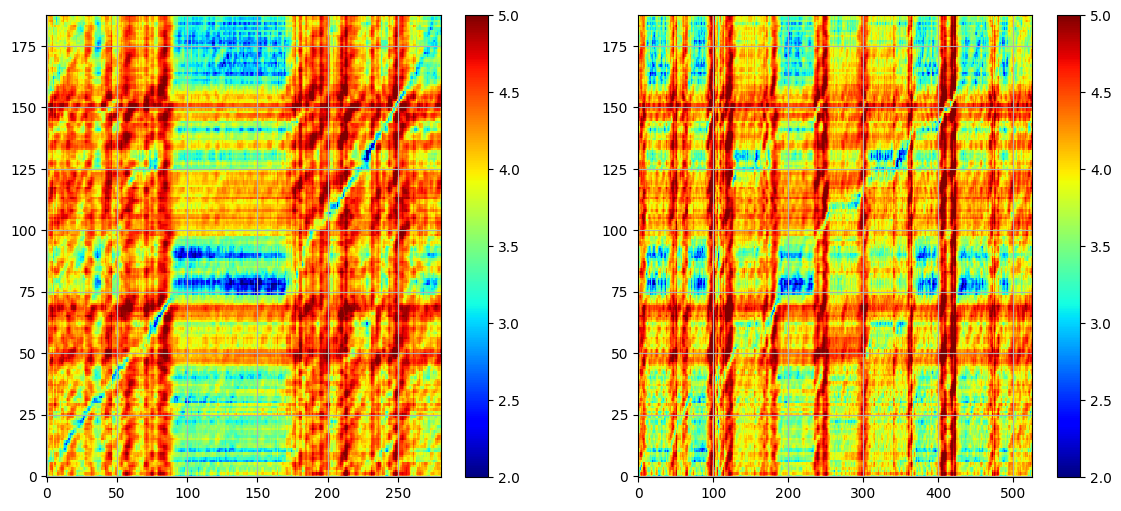

In [ ]:
X3 = cmvn(derivatives(mfcc(filter_bank(frequency_transform(hamming(windowing(x3)))))))
X4 = cmvn(derivatives(mfcc(filter_bank(frequency_transform(hamming(windowing(x4)))))))
X5 = cmvn(derivatives(mfcc(filter_bank(frequency_transform(hamming(windowing(x5)))))))

def eval_square_distance(x, y):
    return  np.sum(x**2,1).reshape(-1,1) + np.sum(y**2,1) - 2*np.dot(x, y.T)

fig=plt.figure(figsize=(14, 6))
plt.subplot(1,2,1)
plt.imshow( np.log( eval_square_distance( X3, X4) ), cmap='jet', interpolation='none',origin='lower', aspect='auto')
plt.clim([2, 5])
plt.colorbar()
plt.grid(None)
plt.subplot(1,2,2)
plt.imshow( np.log( eval_square_distance( X3, X5) ) , cmap='jet', interpolation='none',origin='lower', aspect='auto')
plt.clim([2, 5])
plt.grid(None)
plt.colorbar()

Now it is possible to see which sound in one file corresponds to each sound, can you?

## Exercises

### Exercise 2.1 Frequency
Study two windows with voiced sounds  from each speaker x1 and x2.

Display the waveform and the frequency transform. Can you estimate the pith frequency from the frequency representation ? Is it similar to the one estimated from the waveform ?

In [ ]:
# 2.1 display here the solution

### Exercise 2.2 Cepstrum
Use the same windows from the previous exercise.

Display the waveform and the cepstrum. Can you estimate the pith frequency from the cepstrum representation ? Is it similar to the one estimated from the waveform ?

In [ ]:
# 2.2 display here the solution

### Exercise 2.3 Simple cepstrum based pith frequency estimation

Using the cepstrum sequence of vectors that we store in a matrix as it has been shown in a previous cell, build a simple pitch detector detecting a peak in the signal in the area of interest if we know that a pitch for a male is in a range between 50 and 100Hz and a female pitch is in a range between 100 and 200Hz. Other thresholds and constants can be added arbitrarily to improve the solution, we do not care at this moment if the solution is not general.

Plot the obtained pitch over the image of the cepstrum.

In [ ]:
# 2.3 solution code here

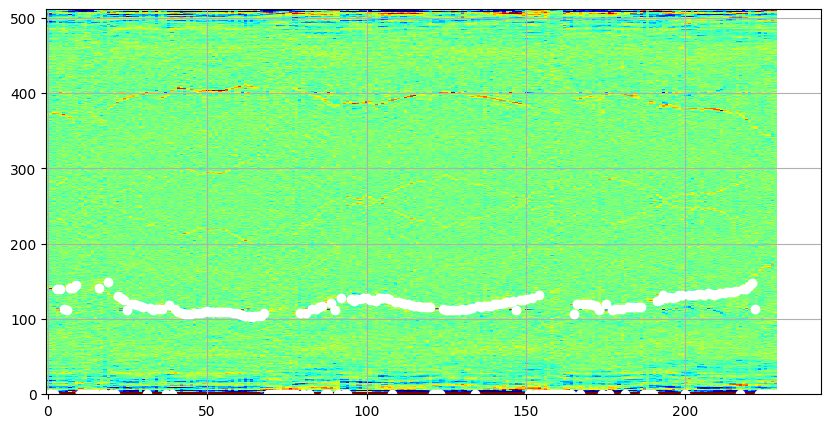

In [ ]:
# a solution

N = len(X1c)
p = np.zeros(N)
for n in range(N):
    value =  np.max( X1c[n, 100:150] )
    if value > 0.1:
      p[n] = np.argmax( X1c[n, 100:150] ) + 100


fig=plt.figure(figsize=(10, 5))
plt.imshow( X1c[2:-1,:].T, cmap='jet', interpolation='none',origin='lower', aspect='auto')
plt.plot(p, 'ow')
plt.clim([-.3, 0.3])
plt.grid(None)